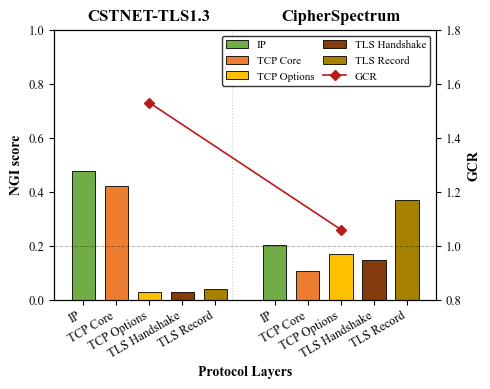

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np

# 1. 风格设置
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False

# 2. 数据准备：转换为字典格式以便按固定顺序读取
raw_data = {
    "CSTNET-TLS1.3": {
        "IP": 0.4791, "TCP Core": 0.4228, "TLS Record": 0.0393, 
        "TLS Handshake": 0.0301, "TCP Options": 0.0286
    },
    "CipherSpectrum": {
        "TLS Record": 0.3698, "IP": 0.2026, "TCP Options": 0.1698, 
        "TLS Handshake": 0.1497, "TCP Core": 0.1082
    }
}

# 强制要求的固定顺序
fixed_order = ["IP", "TCP Core", "TCP Options", "TLS Handshake", "TLS Record"]

expert_gcr = {
    "CSTNET-TLS1.3": 1.5314,
    "CipherSpectrum": 1.0608
}

datasets = ["CSTNET-TLS1.3", "CipherSpectrum"]

# 3. 颜色映射 (严格匹配你提供的 color_map)
color_map_top = {
    "IP": "#70AD47",
    "TCP Core": "#ED7D31",
    "TCP Options": "#FFC000",
    "TLS Handshake": "#843C0C",
    "TLS Record": "#A68100"
}

def draw_final_expert_plot():
    # 稍微增加高度 (4.0) 以兼顾长标签和图例
    fig, ax1 = plt.subplots(figsize=(5.0, 4.0))
    
    current_x = 0
    x_pos, x_labels = [], []
    gcr_x_coords, gcr_vals = [], []
    bar_handles = {}

    # --- 1. 绘制 Expert NGI 条形图 ---
    for i, ds in enumerate(datasets):
        ds_start_x = current_x
        ds_dict = raw_data[ds]
        
        # 严格按照 fixed_order 顺序循环
        for name in fixed_order:
            ngi_val = ds_dict.get(name, 0)
            color = color_map_top.get(name, "gray")
            
            bar = ax1.bar(current_x, ngi_val, color=color, edgecolor='black', 
                          linewidth=0.6, width=0.7, zorder=2)
            
            if name not in bar_handles:
                bar_handles[name] = bar[0]
                
            x_pos.append(current_x)
            x_labels.append(name) # 使用完整名称，不缩写
            current_x += 1
        
        # 数据集中心计算
        ds_center = ds_start_x + (len(fixed_order) - 1) / 2
        gcr_x_coords.append(ds_center)
        gcr_vals.append(expert_gcr[ds])
        
        # 数据集标题外置
        ax1.text(ds_center, 1.02, ds, transform=ax1.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        # 数据集分割
        if i < len(datasets) - 1:
            ax1.axvline(x=current_x - 0.5, color='#CCCCCC', linestyle=':', linewidth=0.8)
            current_x += 0.8 # 间隙稍大，区分两个数据集

    # --- 2. 绘制 GCR 趋势线 ---
    ax2 = ax1.twinx()
    ax2.axhline(y=1.0, color='black', linestyle='--', linewidth=0.7, alpha=0.3)
    line, = ax2.plot(gcr_x_coords, gcr_vals, color='#B71C1C', marker='D', 
                    markersize=5, linewidth=1.2, label='GCR', zorder=5)
    
    # --- 3. 坐标轴与标签 ---
    ax1.set_ylabel("NGI score", fontsize=10, fontweight='bold')
    ax1.set_xlabel("Protocol Layers", fontsize=10, fontweight='bold')
    ax1.set_ylim(0, 1.0) 
    ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    
    ax2.set_ylabel("GCR", fontsize=10, color='black', fontweight='bold')
    ax2.set_ylim(0.8, 1.8)
    
    # X 轴标签：45度旋转，防止长名称重叠
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=8.5)
    
    ax1.tick_params(labelsize=9)
    ax2.tick_params(labelsize=9)

    # --- 4. 图例设置 ---
    handles = [bar_handles[n] for n in fixed_order]
    labels = fixed_order
    handles.append(line)
    labels.append("GCR")

    # 双列显示图例
    ax1.legend(handles, labels, loc='upper right', fontsize=8, 
               frameon=True, edgecolor='black', ncol=2, columnspacing=0.8)

    # 边框
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    plt.tight_layout()
    plt.savefig("../NGI/Layer-Level_Interpretability_Analysis.pdf", bbox_inches='tight')
    plt.show()

draw_final_expert_plot()